This notebook creates static downproj visualizations for each mod. See `dynamic_downproj.ipynb` for these neurons scaled according to a forward pass. 

In [1]:
import torch 
from nnsight import LanguageModel 
model = LanguageModel("meta-llama/Llama-3.1-8B", dispatch=True, device_map="cpu")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [2]:
import matplotlib.pyplot as plt 

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 16

In [3]:
# based on results from neurons_across_sums.ipynb
addition_neurons = {
    "mod_2" : [1712, 10297], # mod 2 
    "mod_5" : [8859, 8887, 3896, 2404, 12728, 13492], # mod 5
    "mod_10" : [8409, 3644, 2955, 251, 11029, 10099, 12154, 11545], # mod 10 
    "mod_20" : [5700, 3650, 13003], # mod 20 
    "mod_50" : [12778, 6339, 8343, 61, 1448, 1768, 2372],  # mod 50
    "mod_100" : [6721, 11096] # mod 100 
}

mlp_output sum_ab probes: cos·sin = -0.0023

  Neuron      cos      sin      |r|    angle ~residue
-------------------------------------------------------
    8409  -0.1590  -0.1858   0.2446   229.5°    6.37
    3644   0.2564   0.1176   0.2821    24.6°    0.68
    2955  -0.3844  -0.0286   0.3855   184.3°    5.12
     251  -0.2305   0.0900   0.2475   158.7°    4.41
   11029  -0.2217   0.2331   0.3217   133.6°    3.71
   10099  -0.0903  -0.2292   0.2463   248.5°    6.90
   12154  -0.2220   0.1881   0.2909   139.7°    3.88
   11545   0.1899  -0.2203   0.2909   310.8°    8.63


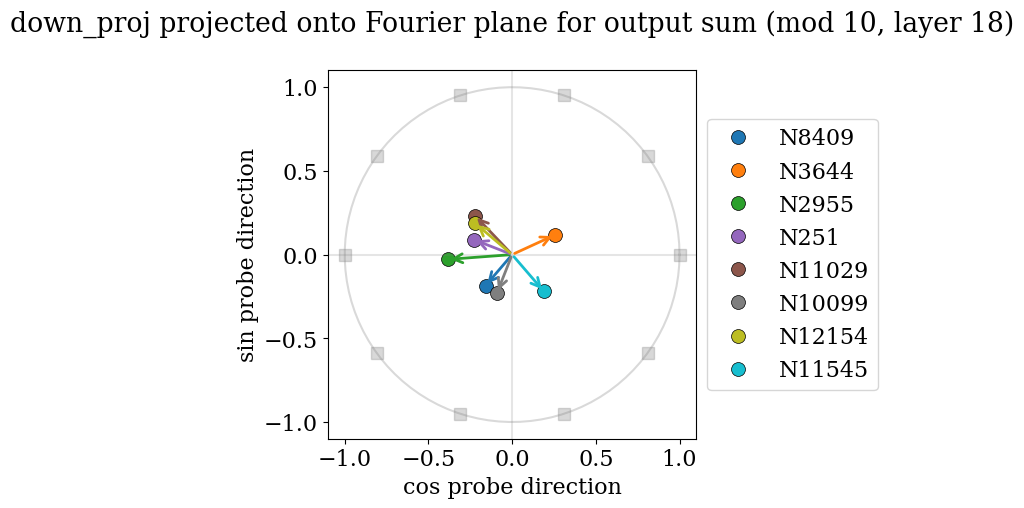

In [6]:
import os 
import numpy as np

T = 10
NEURONS = addition_neurons[f"mod_{T}"]

# Project neuron down_proj directions onto mlp_output sum_ab Fourier probes
PROBES_DIR = "fourier_probes/addition_probes_layer_18_last_token_resid/"

def load_output_probe(period, func_name):
    path = os.path.join(PROBES_DIR, f"probe_period{period}_{func_name}.pt")
    sd = torch.load(path, map_location="cpu", weights_only=True)
    return sd["linear.weight"].squeeze(0)  # (4096,)

w_cos_out = load_output_probe(T, "cos")
w_sin_out = load_output_probe(T, "sin")
d_cos_out = w_cos_out / w_cos_out.norm()
d_sin_out = w_sin_out / w_sin_out.norm()
print(f"mlp_output sum_ab probes: cos·sin = {(d_cos_out @ d_sin_out).item():.4f}")

# down_proj columns: W_down[:, n] is the direction neuron n writes into the residual stream
W_down = model.model.layers[18].mlp.down_proj.weight.detach().float().cpu()  # (4096, 14336)

# we are using the unit vector of cosine probe. how many units in cosine dir 
down_projections = {}  # down_projections[neuron] = (cos_coord, sin_coord)
for n in NEURONS:
    w_n = W_down[:, n]  # (4096,)
    c = (w_n @ d_cos_out).item()
    s = (w_n @ d_sin_out).item()
    down_projections[n] = (c, s)

if T == 2:
    colors = [plt.cm.RdBu(0.8), plt.cm.RdBu(0.2)]
else:
    colors = plt.cm.tab10(np.linspace(0, 1, len(NEURONS)))
fig, ax = plt.subplots(figsize=(7, 7))

radii = []
for i, n in enumerate(NEURONS):
    c, s = down_projections[n]
    r = np.sqrt(c**2 + s**2)
    radii.append(r)
    
    ax.annotate('', xy=(c, s), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=colors[i], lw=2))
    ax.plot(c, s, 'o', color=colors[i], markersize=10,
            markeredgecolor='k', markeredgewidth=0.5, label=f'N{n}')
    
    angle = np.arctan2(s, c)
    residue = (angle / (2 * np.pi / T)) % T

r_ref = 1 # unit circle for reference 
theta = np.linspace(0, 2*np.pi, 100)
ax.plot(r_ref*np.cos(theta), r_ref*np.sin(theta), 'k-', alpha=0.15)
for r in range(T):
    angle = 2 * np.pi * r / T
    ax.plot(r_ref*np.cos(angle), r_ref*np.sin(angle),
            's', color='gray', alpha=0.3, markersize=8)

ax.axhline(0, color='gray', alpha=0.2)
ax.axvline(0, color='gray', alpha=0.2)
ax.set_aspect('equal')
ax.set_xlabel('cos probe direction')
ax.set_ylabel('sin probe direction')
ax.set_title(f'down_proj projected onto Fourier plane for output sum (mod {T}, layer 18)\n')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

# Print table
print(f"\n{'Neuron':>8} {'cos':>8} {'sin':>8} {'|r|':>8} {'angle':>8} {'~residue':>8}")
print('-' * 55)
for n in NEURONS:
    c, s = down_projections[n]
    r = np.sqrt(c**2 + s**2)
    angle_deg = np.degrees(np.arctan2(s, c)) % 360
    residue = (angle_deg / 360) * T
    print(f"{n:>8} {c:>8.4f} {s:>8.4f} {r:>8.4f} {angle_deg:>7.1f}° {residue:>7.2f}")

plt.show()